# Basic Method of OpenCV-Python


### 1.1 type, dir, help

- Python 은 type insentive 언어라  해당 객체의 Class 정보를 알기 어려운 경우가 있음.
- 최근에는 이러한 문제를 해결하기 위하여 Type Annotation 이 사용되지만 강제 사항이 아님. 

In [1]:
import numpy as np 

a = np.array([1.0, 5.0, 3.9])
# check class of instance 
print(type(a))

# check the attributes and functions
print(dir(a))

# check usage of a function
help(a.sort)

<class 'numpy.ndarray'>
['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_prepare__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdi

### 1.2 설치된 OpenCV 지원 기능 확인 

In [2]:
import cv2

# 지원 기능 확인 
print(cv2.getBuildInformation())


General configuration for OpenCV 4.6.0 =====================================
  Version control:               4.6.0

  Extra modules:
    Location (extra):            D:/a/opencv-python/opencv-python/opencv_contrib/modules
    Version control (extra):     4.6.0

  Platform:
    Timestamp:                   2022-06-07T10:18:33Z
    Host:                        Windows 10.0.17763 AMD64
    CMake:                       3.22.5
    CMake generator:             Visual Studio 14 2015
    CMake build tool:            MSBuild.exe
    MSVC:                        1900
    Configuration:               Debug Release

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 FP16 AVX AVX2
      requested:                 SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (16 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2
      FP16 (0 files):            + SSSE

## 2. image 읽고 화면에 표시하기

- OpenCV는  다음과 같이 대부분의 이미지 파일 포맷을 지원 함.
   -  Windows Bitmaps	.bmp, .dib	항상 지원되는 기본 포맷
   - JPEG	.jpeg, .jpg, .jpe	가장 일반적인 손실 압축 포맷
   - JPEG 2000	.jp2	JPEG보다 개선된 압축률과 품질
   - PNG	.png	무손실 압축 및 알파 채널(투명도) 지원
   -  WebP	.webp	구글에서 개발한 웹 최적화 포맷
   - Portable Formats	.pbm, .pgm, .ppm, .pxm, .pnm	흑백/그레이스케일/컬러용 무압축 포맷
   - TIFF	.tiff, .tif	무손실 압축 및 고품질 이미지 (16/32비트 지원)
   - HDR/Exr	.hdr, .pic, .exr	높은 동적 범위를 가진 고사양 그래픽 데이터
   - AVIF	.avif	최신 고효율 이미지 포맷 (OpenCV 4.8.0 이상 지원)

- 수업에서는 png 와 jpg 포맷을 주로 사용

- JPG 포맷
   - jpeg 손실 압축을 사용
   - 파일 사이즈가 작으나 (RAW 데이터의 1/20 이하)
   - 화질 감소 (화소값이 변경되어 저장됨) 
   
- PNG 포맷 
   - 무손실 압축을 사용 
   - 파일 사이즈가 크나 (RAW 데이터의 1/10 이상)
   - 화소값이 정확히 동일한 값이 저장됨 
   - 수업에서는 정확이 동일한 결과를 얻어야 하므로 기본적으로 PNG를 사용. 


#### 파일 읽기, 읽은 데이터 확인 

read Lena.png
shape: (404, 388, 3)
dtype: uint8


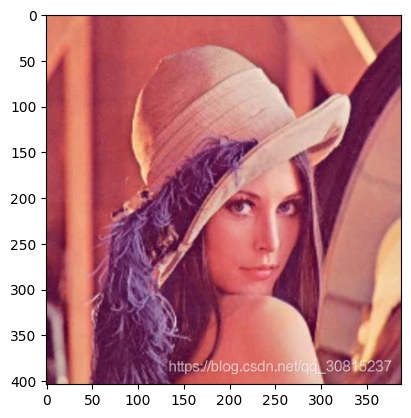

In [3]:
imgfilePath = 'Lena.png'
img = cv2.imread(imgfilePath)
# Check if image was successfully read.
assert img is not None

import matplotlib.pyplot as plt

#plt.imshow(img)   # matplot 은 RGB 채멀을 가정
plt.imshow(img[:,:,::-1]) # BGR to RGB  
print('read {}'.format(imgfilePath))
print('shape:', img.shape)
print('dtype:', img.dtype)

#### PNG VS JPG 

- 압축률을 조절하는 Option 이 존재 
- PNG 의 경우: [cv2.IMWRITE_PNG_COMPRESSION, 0-100]
- JPG 의 경우: [cv2.IMWRITE_JPEG_QUALITY, 0-100]

jpeg, same  pixels: 135111
png, same  pixels: 470256
total pixels: 470256


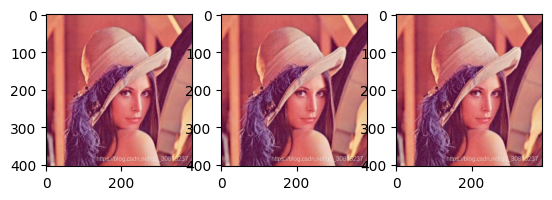

In [4]:
imgfilePath = 'Lena.png'
img = cv2.imread(imgfilePath)

cv2.imwrite("Lena.jpg", img)
img_jpg = cv2.imread("Lena.jpg")

cv2.imwrite("Lena2.png", img)
img_png = cv2.imread("Lena2.png")

import numpy as np 

print("jpeg, same  pixels:", np.count_nonzero(img == img_jpg))  
print("png, same  pixels:",  np.count_nonzero(img == img_png))
print("total pixels:", img.shape[0]*img.shape[1]*img.shape[2])
      
plt.subplot(1,3, 1) 
plt.imshow(img[:,:,::-1])
plt.subplot(1,3, 2) 
plt.imshow(img_jpg[:,:,::-1])
plt.subplot(1,3, 3) 
plt.imshow(img_png[:,:,::-1])


## 3. image paint 하기 

- 영상 프로그램을 디버깅하고 사용자에게 결과를 보여 주기 위해서 이미지에 글자나 간단한 도형으로 표시를 하는것 이 필요
- 글자 쓰기, 선 그리기, 원그리기, 네모그리기 외에 다양한 도형을 표시할 수 있음.

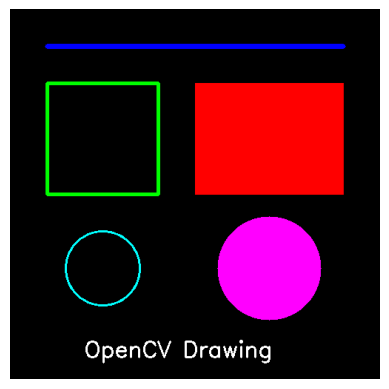

In [5]:
# 1. 빈 이미지 생성 (500x500 사이즈, 3채널 컬러, 배경은 검은색)
# 배경을 흰색으로 만들고 싶다면 np.full((500, 500, 3), 255, dtype=np.uint8) 사용
img = np.zeros((500, 500, 3), dtype=np.uint8)

# 2. 선 그리기 (Line)
# cv2.line(이미지, 시작점, 끝점, 색상, 두께)
cv2.line(img, (50, 50), (450, 50), (255, 0, 0), 5)  # 파란색 선

# 3. 직사각형 그리기 (Rectangle)
# cv2.rectangle(이미지, 좌상단점, 우하단점, 색상, 두께)
# 두께에 -1을 넣으면 내부가 채워집니다.
cv2.rectangle(img, (50, 100), (200, 250), (0, 255, 0), 3)       # 초록색 테두리
cv2.rectangle(img, (250, 100), (450, 250), (0, 0, 255), -1)    # 빨간색 채우기

# 4. 원 그리기 (Circle)
# cv2.circle(이미지, 중심점, 반지름, 색상, 두께)
cv2.circle(img, (125, 350), 50, (255, 255, 0), 2)   # 하늘색(Cyan) 원
cv2.circle(img, (350, 350), 70, (255, 0, 255), -1)  # 보라색(Magenta) 채워진 원

# 5. 글자 쓰기 (PutText)
# cv2.putText(이미지, 텍스트, 위치(좌하단), 폰트, 크기, 색상, 두께)
text = "OpenCV Drawing"
cv2.putText(img, text, (100, 470), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)


import matplotlib.pyplot as plt

# 3. Matplotlib으로 출력
plt.imshow(img[:,:,::-1])
plt.axis('off') # 가로세로 축 숫자 숨기기
plt.show()

## 4. 사용자 입출력 & OpenCV 내장화면출력 


- 입력 종류: 키보드 문자 입력,  마우스 버튼과 이동 이벤트 
- 이를 사용하려면 OpenCV의 자체 UI 이벤트 처리 방식을 사용해야함
    - cv2.waytKey(ms)  # ms: sleep 시간 0 이면 입력이 들어오기 전까지 무한히 기달림. 반환: 입력키 2 byte (CTRL byte + ASCII Byte) 
    - cv2.imshow(windowname, img) 
    - **주의**: Jupyter notebook에서 실행시 윈도우가 별도로 뜸! 
 
- 키보드 입력
    - waitKey(ms) 의 반환값으로 전달됨 
       
- 마우스 입력:  콜백함수로 등록 및 호출
    - 콜백 등록:  cv2.setMouseCallback(window_name, callback_func)
    - 콜백 함수 포맷: def mouse_callback(event, x, y, flags, param)
        - event: 마우스 이동, 버튼눌림, 버튼띠움, 더블클릭, 휠이동 등 (예 cv2.EVENT_LBUTTONDOWN, cv2.EVENT_MOUSEMOVE )
        - x,y : 윈도위내의 좌표값
        - flags: CTRL/SHIFT/ALT 키가 함께 눌렸는지 여부 

In [ ]:
import cv2
import numpy as np

# 마우스 콜백 함수 정의
def draw_circle(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN: # 왼쪽 버튼 클릭 시
        cv2.circle(img, (x, y), 20, (255, 0, 0), -1)

img = np.zeros((500, 500, 3), np.uint8)
cv2.namedWindow('Mouse Interaction')
cv2.setMouseCallback('Mouse Interaction', draw_circle)

print("ESC를 누르면 종료됩니다.")

while True:
    cv2.imshow('Mouse Interaction', img)
    
    # 키보드 입력 처리 (ESC 키의 아스키 코드: 27)
    if cv2.waitKey(1) & 0xFF == 27:    # 또는  cv2.waitkey(1) == ord('q') 
        break

cv2.destroyAllWindows()  # 모든 윈도우를 닫음

ESC를 누르면 종료됩니다.


### 끝